# Plot Spects for Match vs Mismatch Trials

For Load-2 models — this is normalizing by cutting out first 1/4 of fixation, and normalizing by the rest of the period


In [1]:
import numpy as np 
from matplotlib import pyplot as plt 
import os
import sys
import importlib
import scipy.io

# import utils path
sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import spect_utils as su 
from bootstrap_method import *

## Load IPSCs

In [2]:
task_load = 2
n_neurons = 400
delay = 50

proj_dir = '/home/nuttidalab/Documents/spikeRNN/'
ipsc_dir = proj_dir + f'models/letters/load_{task_load}/IPSCs/'
model_dir = proj_dir + f'models/letters/load_{task_load}/'

# get all model IPSC files and model files
model_fnames = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f))]
print(f'Found {len(model_fnames)} model files')

Found 30 model files


Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_003605.mat (1/30)


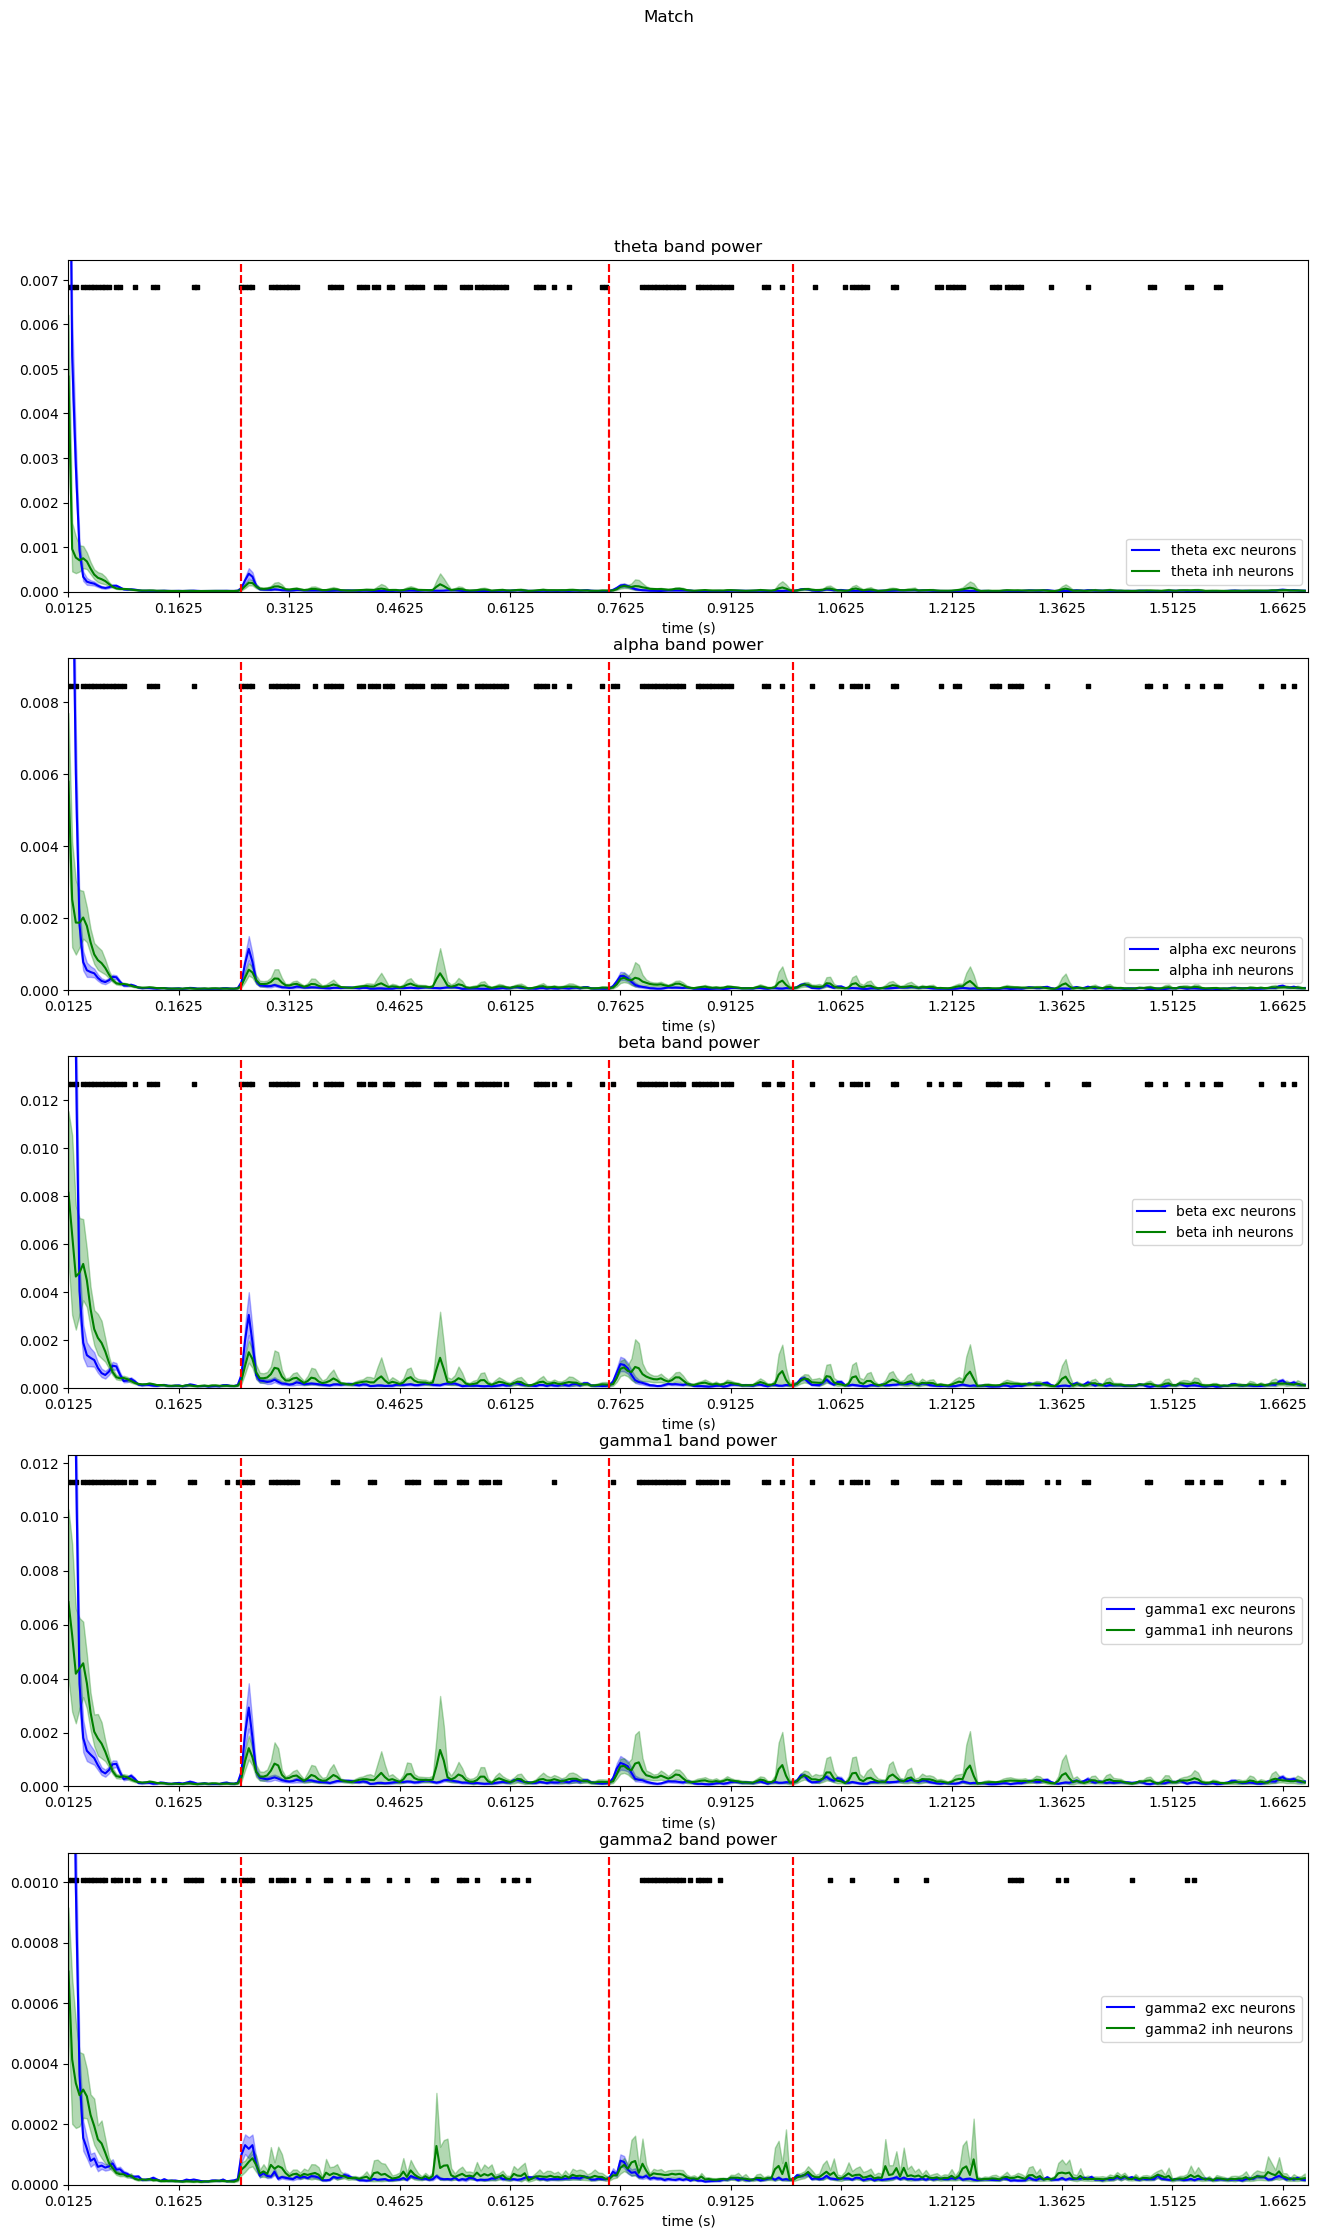

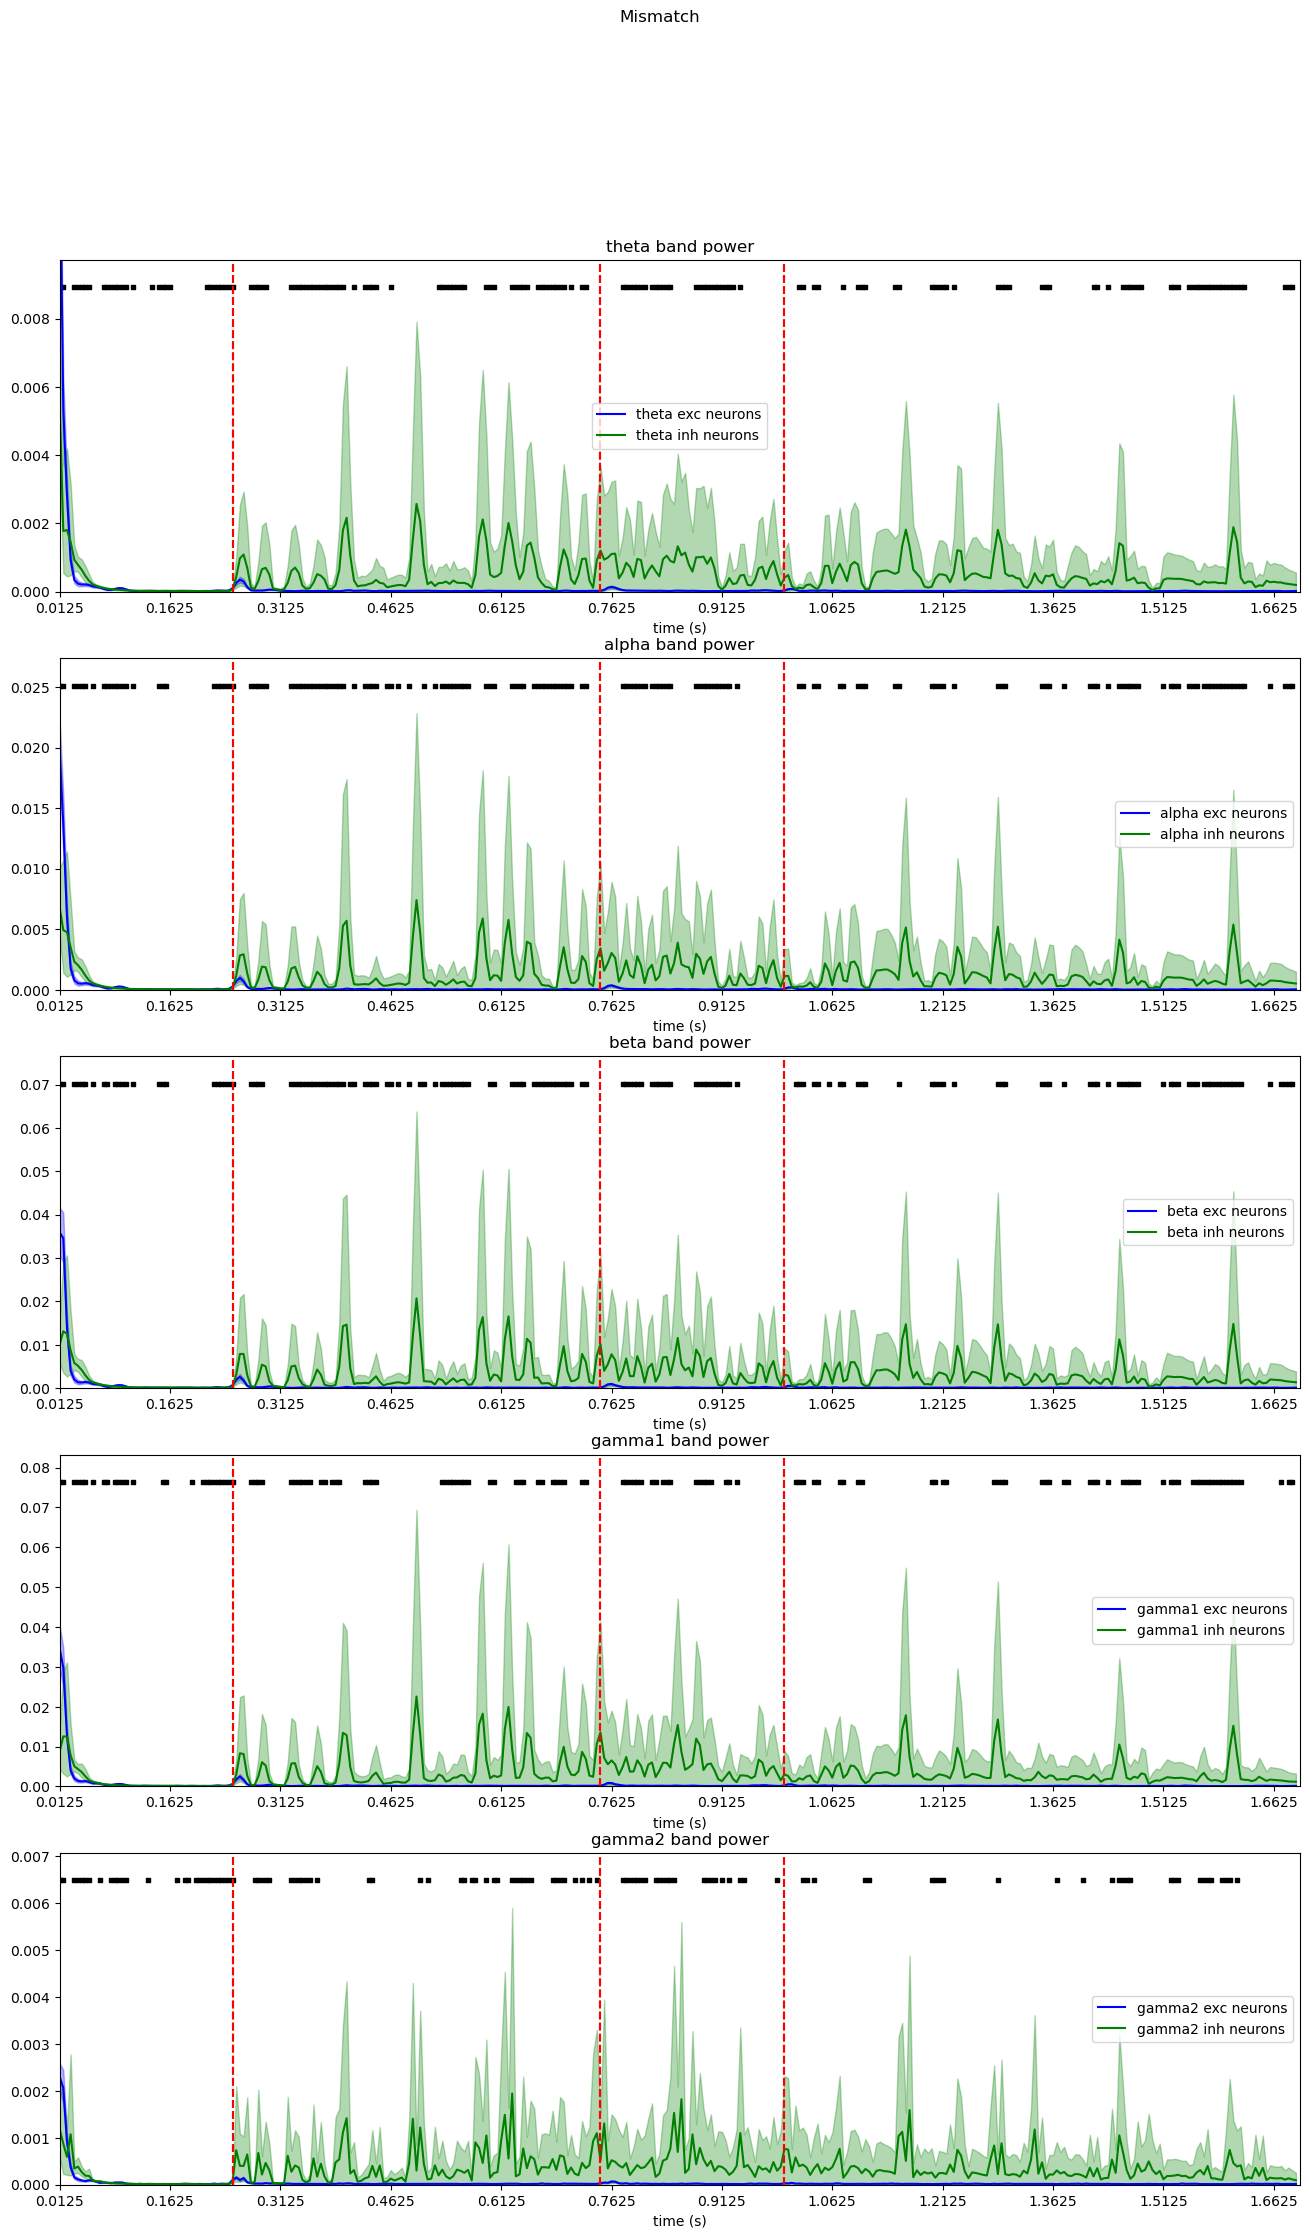

In [16]:
importlib.reload(su)

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_{model_fname}'
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)

    ipscs_match = model_ipsc['ipscs_match']
    ipscs_mismatch = model_ipsc['ipscs_mismatch']
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    stim_letters_all = model_ipsc['stim_letters_all']
    probe_letters_all = np.squeeze(model_ipsc['probe_letters_all'])

    # get timing info
    settings = {
        'T': model_ipsc['T'][0][0],
        'delay': model_ipsc['delay'][0][0],
        'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
        'stim_dur': model_ipsc['stim_dur'][0][0],
        'probe_dur': model_ipsc['probe_dur'][0][0],
    }

    fs_rate = 200
    fs_ds = 1000

    T = int(settings['T']/fs_rate*fs_ds)
    stim_on = int(settings['stim_on']/fs_rate*fs_ds)
    stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
    probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
    response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

    # get exc/inh indices
    temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    exc_ind = np.where(temp['exc'] == 1)[0]
    inh_ind = np.where(temp['inh'] == 1)[0]
    del temp

    # spect params
    nperseg=25
    noverlap = nperseg//1.2
    nfft = nperseg*20

    f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    
    # get bootstrap confidence intervals
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match[exc_ind,:,:], s_match[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='exc neurons', neur2_label='inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Match',
                  p_sig = 0.05, band_range = [], time_range = [])
    
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_mismatch[exc_ind,:,:], s_mismatch[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='exc neurons', neur2_label='inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Mismatch',
                  p_sig = 0.05, band_range = [], time_range = [])

    
    break
    
    

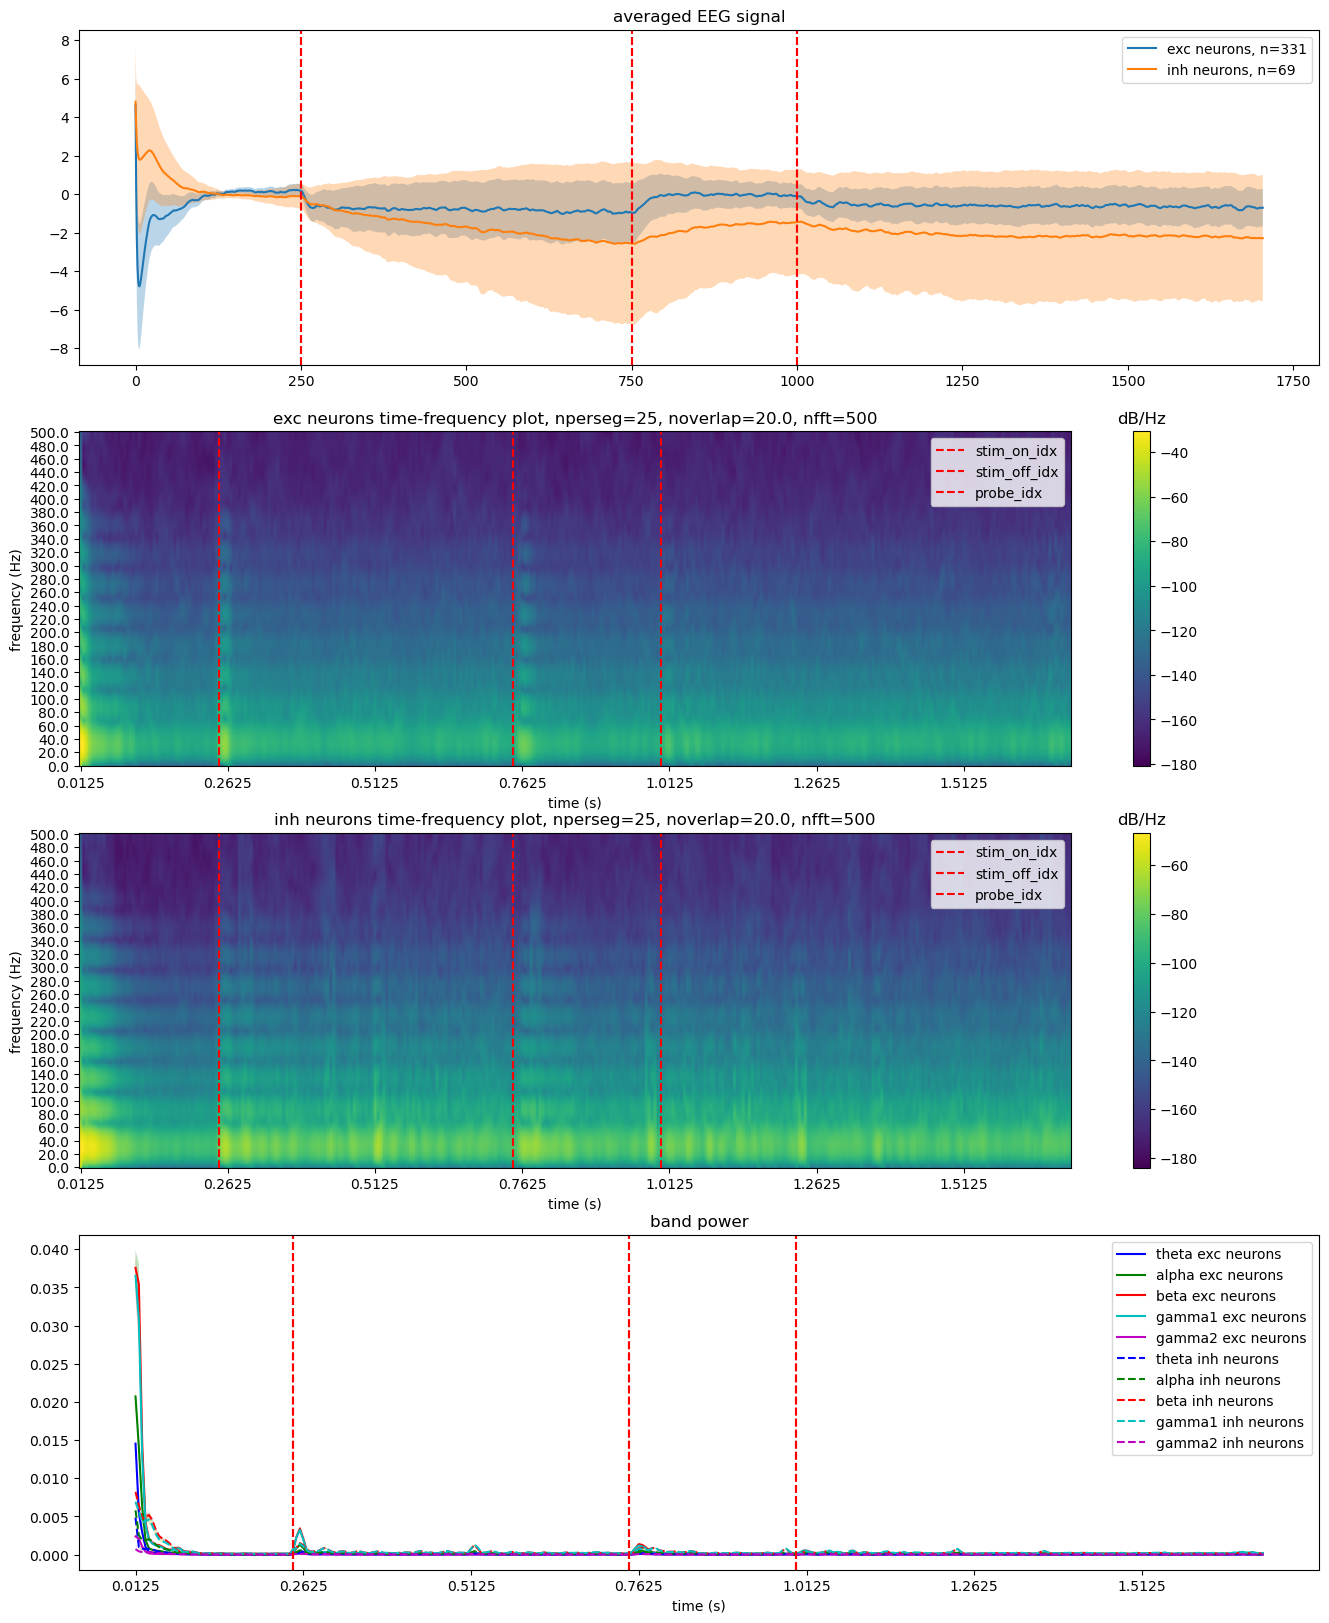

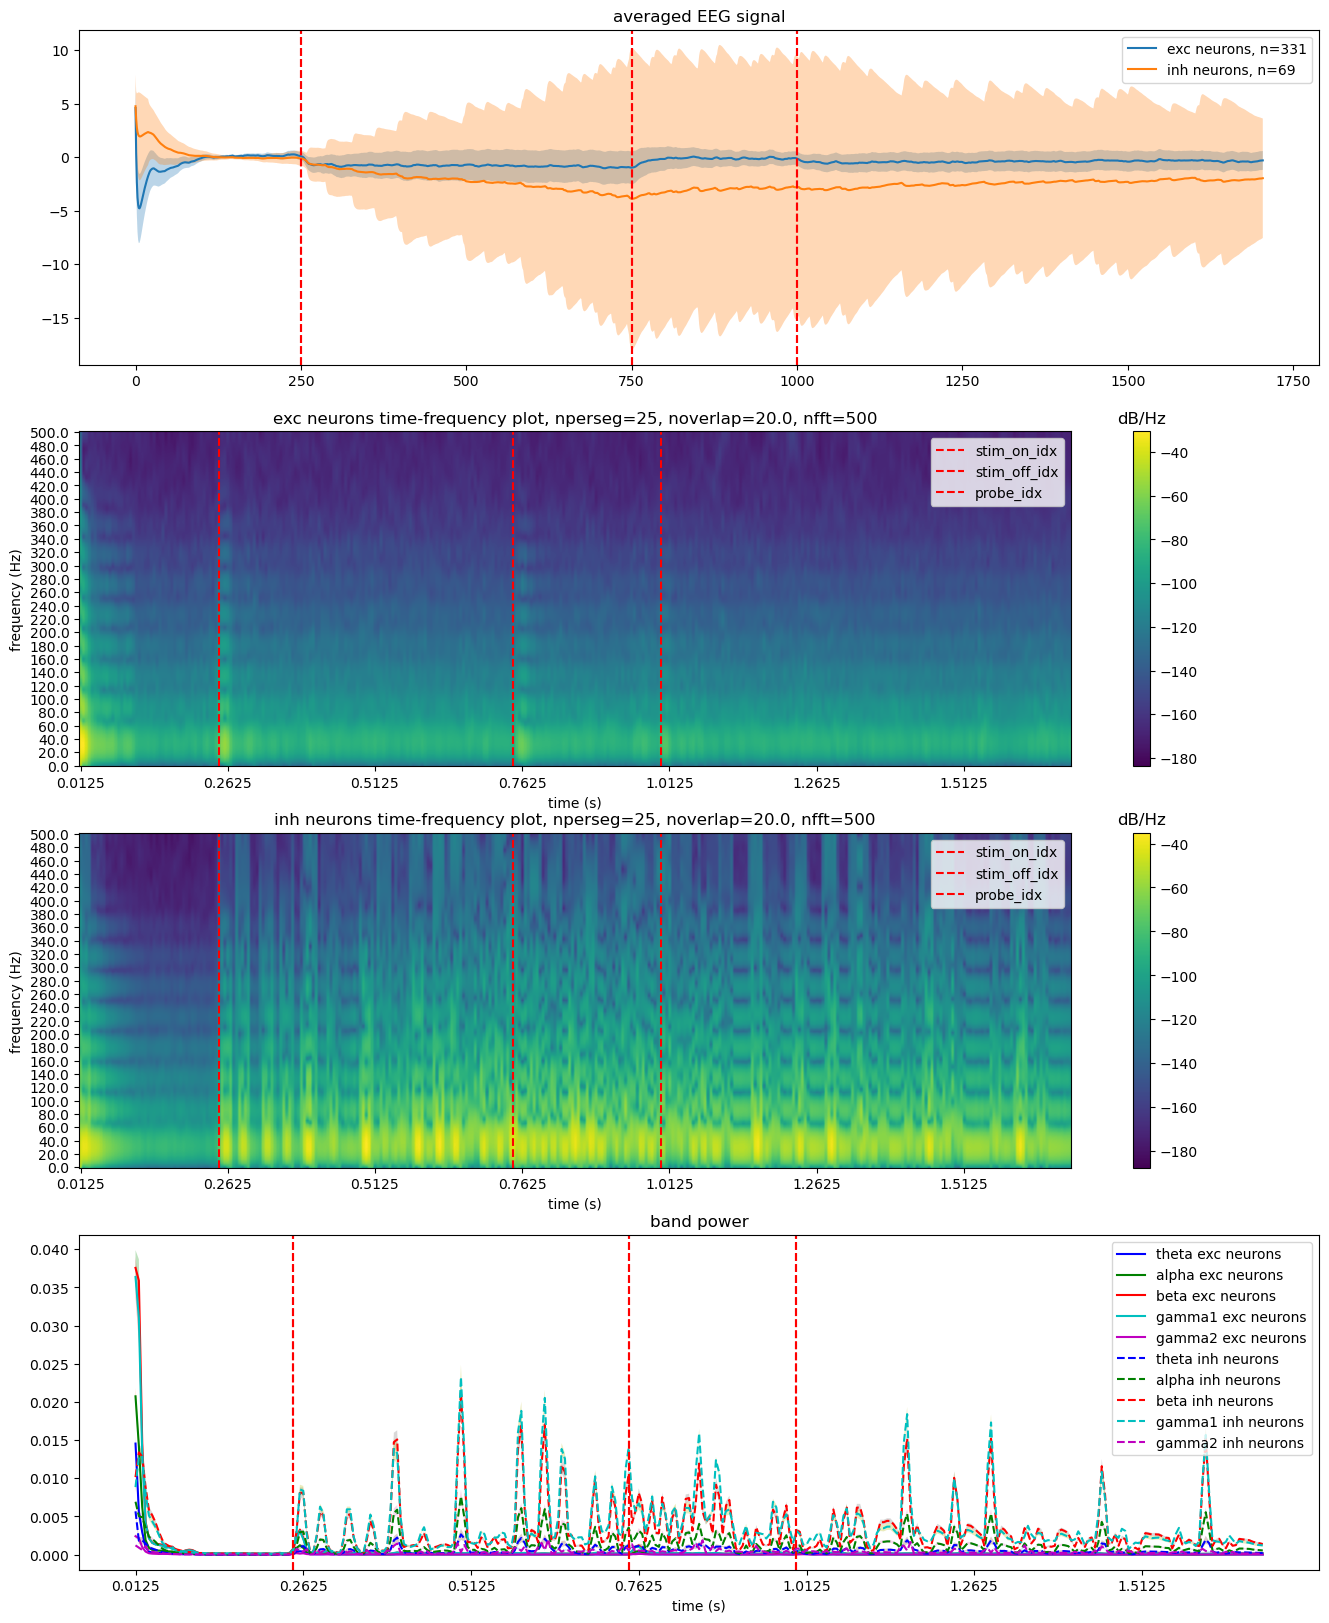

In [21]:
f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=1, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                            f_cutoff=0, plot=1, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                            t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                            EEG_range = [], spect_range = [], band_range = [])

Processing Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_003605.mat (1/30)


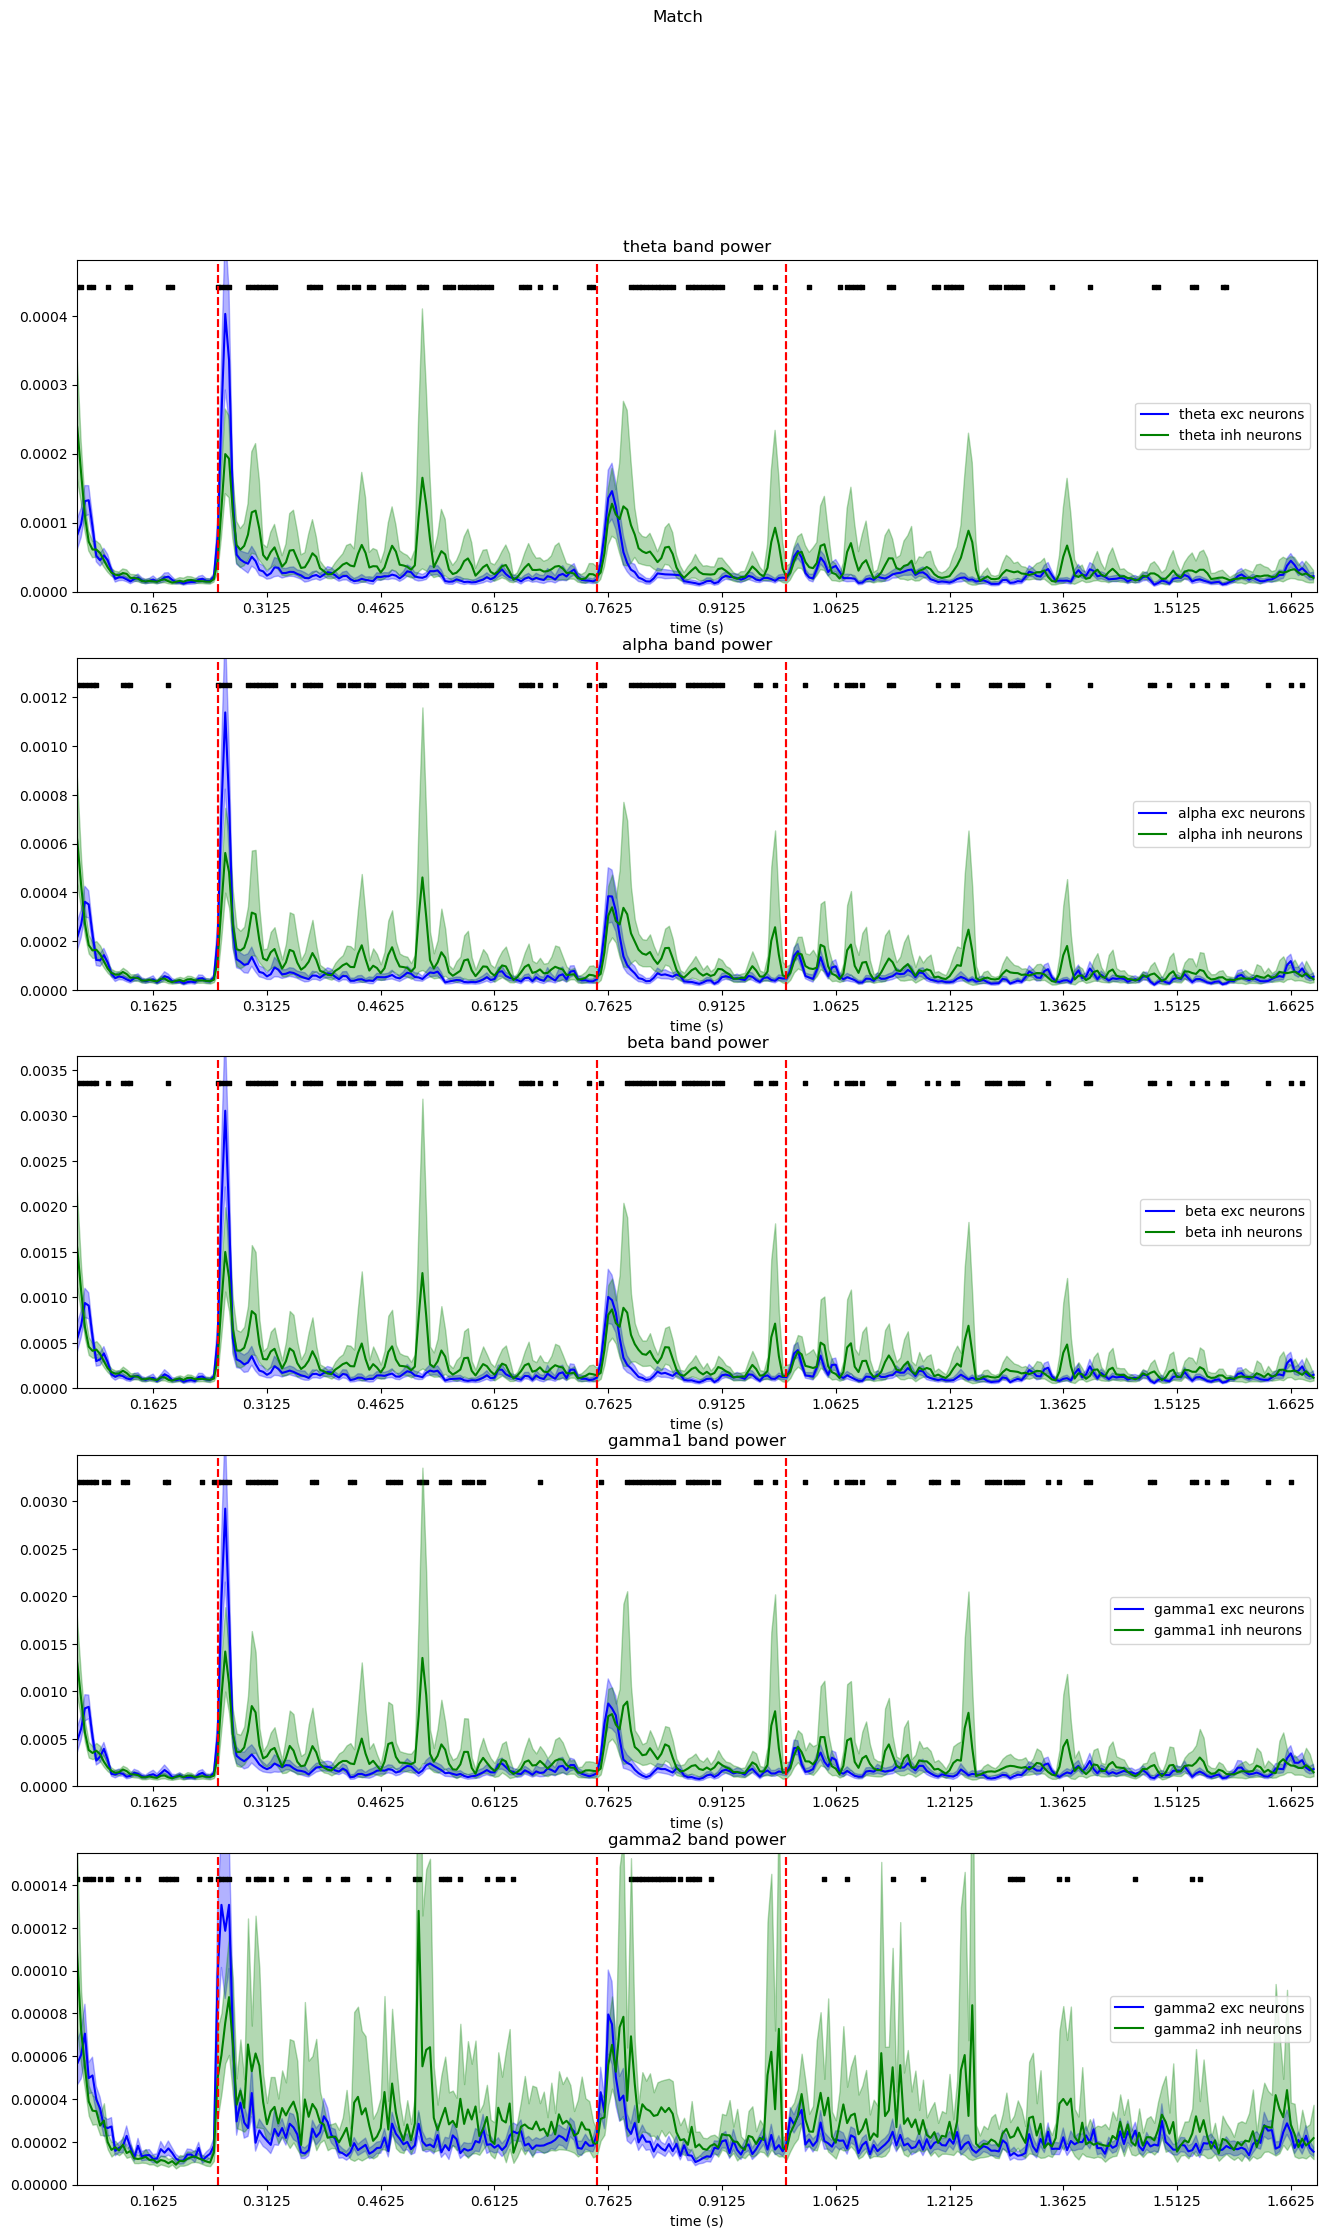

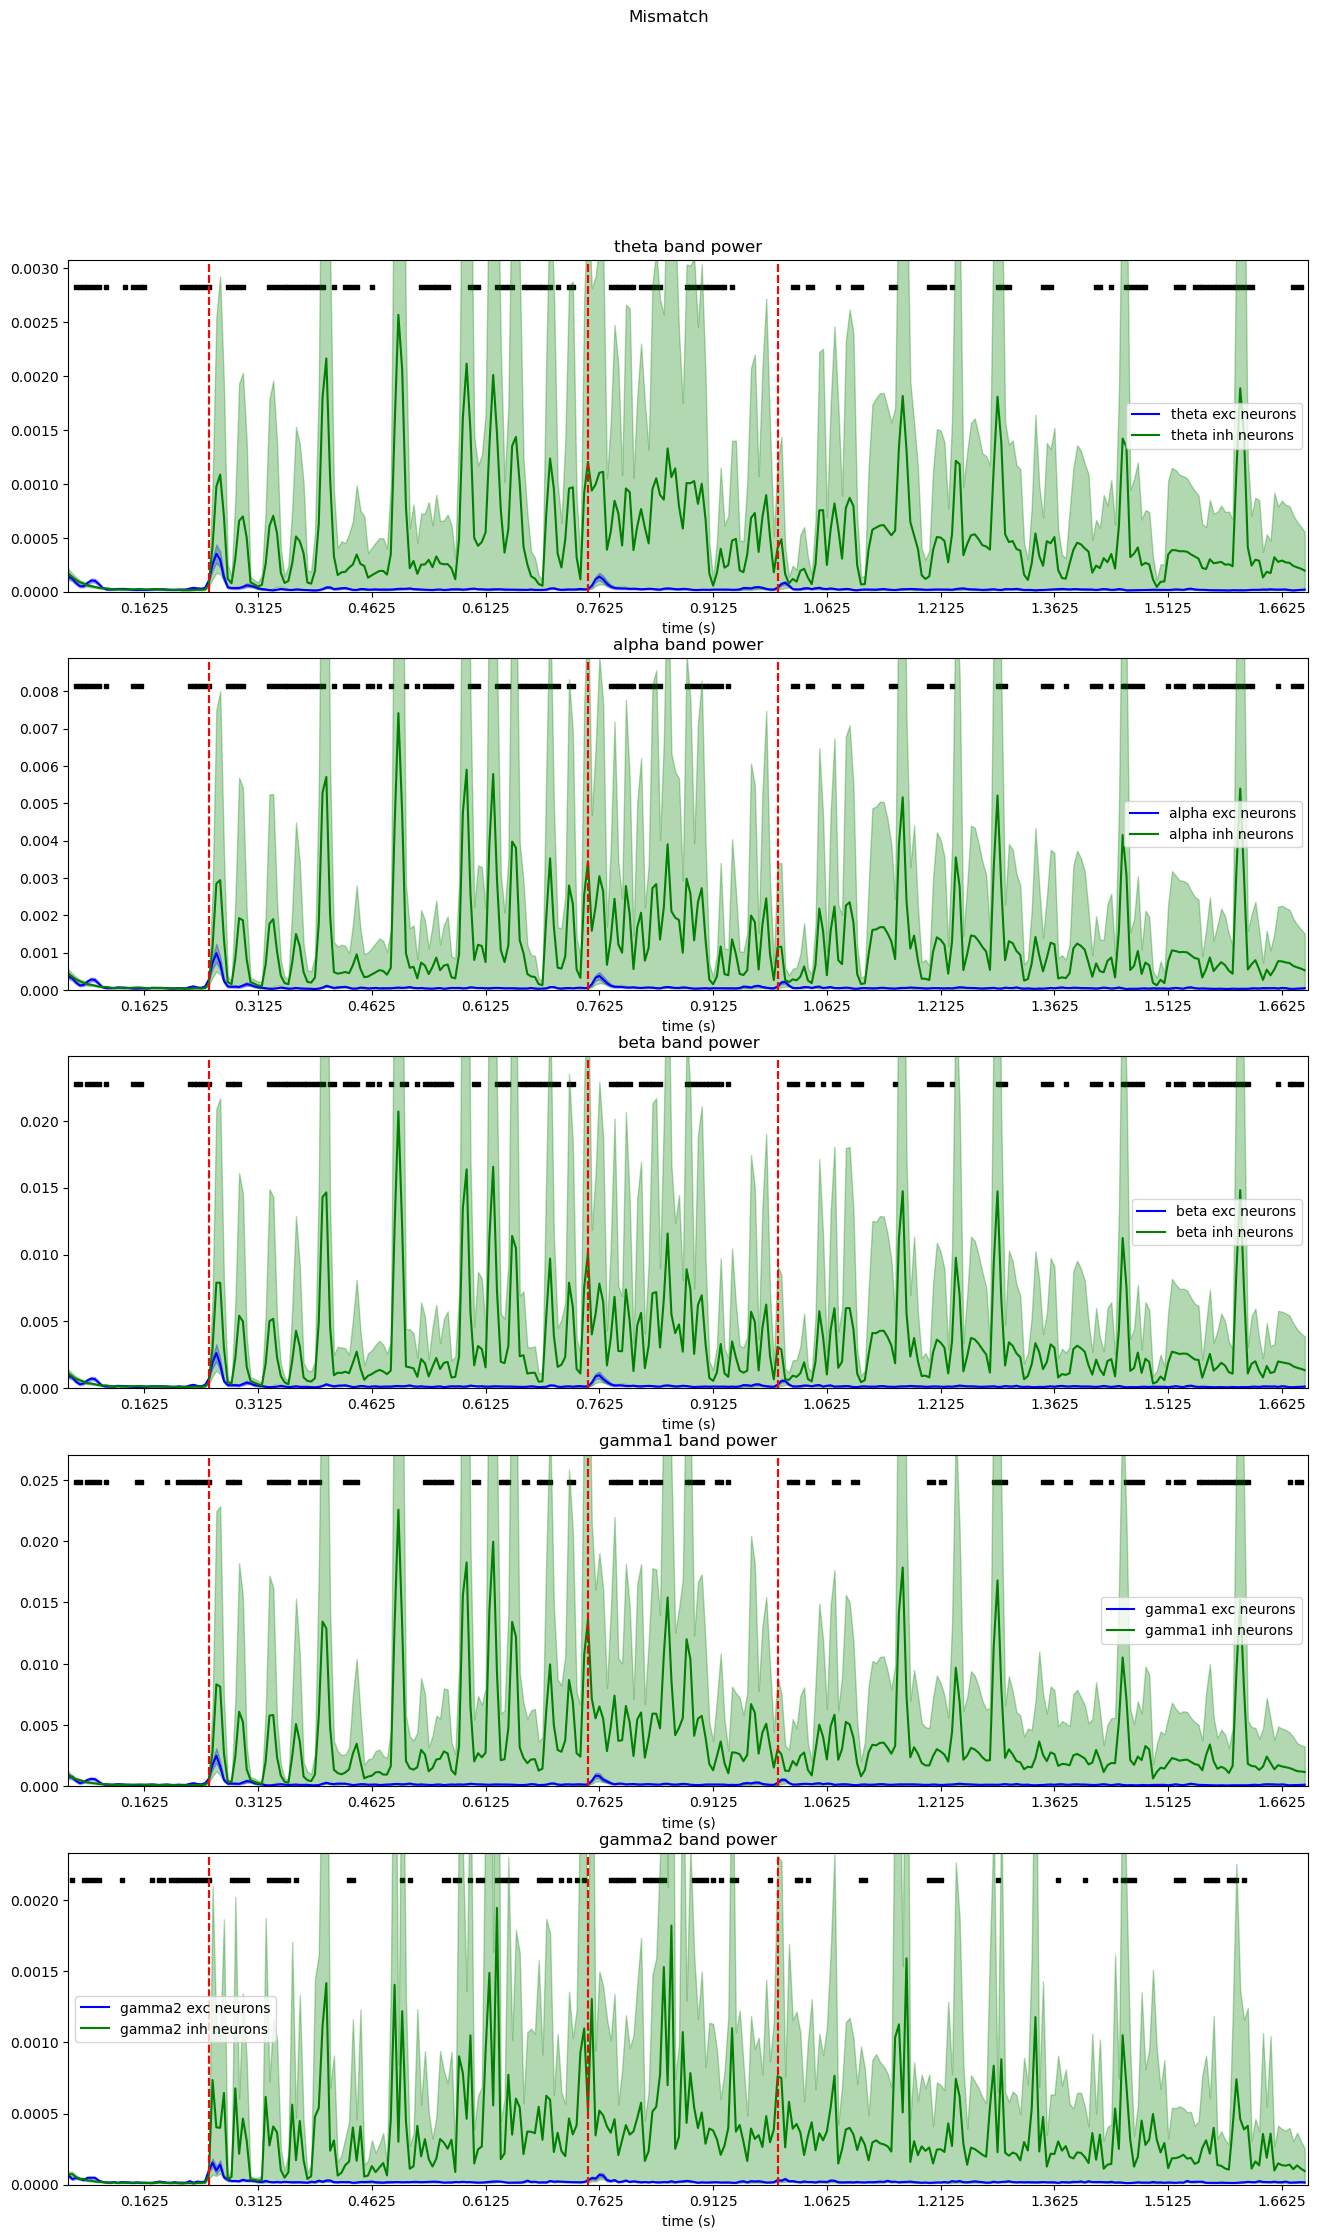

In [20]:
importlib.reload(su)

for i, model_fname in enumerate(model_fnames):
    print(f'Processing {model_fname} ({i+1}/{len(model_fnames)})')

    # get IPSC filename and load
    model_ipsc_fname = f'IPSC_match_delay{delay}_{model_fname}'
    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)

    ipscs_match = model_ipsc['ipscs_match']
    ipscs_mismatch = model_ipsc['ipscs_mismatch']
    perf = np.squeeze(model_ipsc['perf'])
    labels = np.squeeze(model_ipsc['labels'])
    stim_letters_all = model_ipsc['stim_letters_all']
    probe_letters_all = np.squeeze(model_ipsc['probe_letters_all'])

    # get timing info
    settings = {
        'T': model_ipsc['T'][0][0],
        'delay': model_ipsc['delay'][0][0],
        'stim_on': model_ipsc['stim_on'][0][0]-1, # -1 to make it 0-indexed
        'stim_dur': model_ipsc['stim_dur'][0][0],
        'probe_dur': model_ipsc['probe_dur'][0][0],
    }

    fs_rate = 200
    fs_ds = 1000

    T = int(settings['T']/fs_rate*fs_ds)
    stim_on = int(settings['stim_on']/fs_rate*fs_ds)
    stim_off = int((settings['stim_on'] + settings['stim_dur'])/fs_rate*fs_ds)
    probe_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'])/fs_rate*fs_ds)
    response_on = int((settings['stim_on'] + settings['stim_dur'] + settings['delay'] + 10)/fs_rate*fs_ds)

    # get exc/inh indices
    temp = scipy.io.loadmat(model_dir + model_fname, variable_names=['exc', 'inh'])
    exc_ind = np.where(temp['exc'] == 1)[0]
    inh_ind = np.where(temp['inh'] == 1)[0]
    del temp

    # spect params
    nperseg=25
    noverlap = nperseg//1.2
    nfft = nperseg*20

    f, t, s_match = su.compare_avg_spect(ipscs_match, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    f, t, s_mismatch = su.compare_avg_spect(ipscs_mismatch, fs_ds, nperseg, noverlap, nfft, exc_ind, inh_ind,
                               f_cutoff=0, plot=0, stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                               t_skip=50, f_skip=10, trials1_label='exc neurons', trials2_label='inh neurons',
                               EEG_range = [], spect_range = [], band_range = [])
    
    # get bootstrap confidence intervals
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_match[exc_ind,:,:], s_match[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='exc neurons', neur2_label='inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Match',
                  p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])
    
    band_avg, band_err, band_pdiff = su.compare_two_spect_groups_bootstrap(f, t, s_mismatch[exc_ind,:,:], s_mismatch[inh_ind,:,:],
                  stim_on=stim_on/fs_ds, stim_off=stim_off/fs_ds, probe=probe_on/fs_ds, 
                  t_skip=30, f_skip=10, neur1_label='exc neurons', neur2_label='inh neurons',
                  nboot = 1000, CI_int = (2.5, 97.5), random_seed = 820, title='Mismatch',
                  p_sig = 0.05, band_range = [], time_range = [(stim_on/4)/fs_ds, np.nan])

    
    break
    
    

In [ ]:
for i, model_ipsc_fname in enumerate(model_ipsc_fnames):
    print(f'Processing {model_ipsc_fname} ({i+1}/{len(model_ipsc_fnames)})')

    model_ipsc = scipy.io.loadmat(ipsc_dir + model_ipsc_fname)

    ipscs_match = model_ipsc['ipscs_match']
    ipscs_mismatch = model_ipsc['ipscs_mismatch']
    perf = model_ipsc['perf']
    labels = model_ipsc['labels']
    stim_letters_all = model_ipsc['stim_letters_all']
    probe_letters_all = model_ipsc['probe_letters_all']
    
    if i == 0:
        ipsc_all = model_ipsc
    else:
        ipsc_all = np.concatenate((ipsc_all, model_ipsc), axis=0)